In [1]:
#Imports
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import pandas as pd
import scipy.stats as stats 
import matplotlib.colors as mcolors
import matplotlib.lines as mlines
import tkinter as tk
from tkinter import filedialog
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.colors import ListedColormap
import matplotlib.cm as cm
from matplotlib.ticker import MaxNLocator
from scipy.signal import find_peaks
from scipy.ndimage import gaussian_filter1d
from tqdm import tqdm

In [2]:
# Checking if processing rods or GB/GI

processing_type = input("Are you processing shapes (Y) or GB/GI ratio's (N)?")

Are you processing shapes (Y) or GB/GI ratio's (N)? N


In [3]:
#Input directory and file saving function 
root = tk.Tk()
root.withdraw()
print("If pop up box not seen minimise spyder and select folder wanted for analysis")
#folder_path = filedialog.askdirectory(title='Select input folder')
#save_path = filedialog.askdirectory(title='Select Folder to Save Plot')

    
def save_plot_with_folder_dialog(fig, default_filename='plot.jpeg'):
    root = tk.Tk()
    root.withdraw()  # Hide the root window

    folder_path = filedialog.askdirectory(title='Select Folder to Save Plot')
    if not folder_path:
        print("Save cancelled.")
        return

    full_path = os.path.join(folder_path, default_filename)
    fig.savefig(full_path)
    print(f"Plot saved to: {full_path}")
    
def save_plot_to_folder(fig, folder_path, filename='plot.jpeg'):
    if not os.path.exists(folder_path):
        os.makedirs(folder_path)  # Create the folder if it doesn't exist
    
    full_path = os.path.join(folder_path, filename)
    fig.tight_layout()
    fig.savefig(full_path, dpi=1000, bbox_inches='tight')
    print(f"Plot saved to: {full_path}")


If pop up box not seen minimise spyder and select folder wanted for analysis


In [4]:
#Colourmap formatting
# Change c1 and c2 based on the min and max colours to be chosen 

def hex_to_RGB(hex_str):
    
    """ #FFFFFF -> [255,255,255]"""
    
    return [int(hex_str[i:i+2], 16) for i in range(1,6,2)]

def get_color_gradient(c1, c2, n):

    assert n > 1
    c1_rgb = np.array(hex_to_RGB(c1))/255
    c2_rgb = np.array(hex_to_RGB(c2))/255
    mix_pcts = [x/(n-1) for x in range(n)]
    rgb_colors = [((1-mix)*c1_rgb + (mix*c2_rgb)) for mix in mix_pcts]
    return ["#" + "".join([format(int(round(val*255)), "02x") for val in item]) for item in rgb_colors]


colors=[]
c1='#1A85FF'#deep blue
c2='#D41159' # deep pink
c3= '#744db0' # purple

GB_U_color = "5CBBFF"
GI_U_color = "003357"
GB_P_color = "D69AAB"
GI_P_color = "8D1730"

In [5]:
# Gaussian fitting (Multigaussian) 
# Function to model N Gaussians
def multi_gaussian(x, *params):
    n = len(params) // 3
    y = np.zeros_like(x)
    for i in range(n):
        amp = params[i * 3]
        cen = params[i * 3 + 1]
        wid = params[i * 3 + 2]
        y += amp * np.exp(-((x - cen) ** 2) / (2 * wid ** 2))
    return y

# Auto-generate initial guess based on data
def estimate_guess_from_data(x, y, prominence=0.1, distance=10):
    y_smooth = gaussian_filter1d(y, sigma=2)
    peaks, _ = find_peaks(y_smooth, prominence=prominence, distance=distance)
    
    # Sort peaks by height (amplitude) and limit to top 2
    if len(peaks) > 2:
        sorted_indices = np.argsort(properties['prominences'])[::-1][:2]
        peaks = peaks[sorted_indices]

    guess = []
    for i in peaks:
        amp = y[i]
        cen = x[i]
        wid = 0.001 # Adjust based on data
        guess += [amp, cen, wid]
    
    return guess, len(peaks)


In [6]:
#Processing for hexagons, rods and other
# Setting up initial parameters to change from fitting: 
# number of rows in txt files to skip

rows = 3


# General iteration for creating values: 
def fit_gaussian (file_name, rows): 
    # Pass the file path (string) to open() with a specified encoding
    with open(file_name, 'r', encoding='utf-8', errors='replace') as f:
        data = np.loadtxt(f, skiprows=rows)
    #with open(file_name, 'r', encoding='utf-8', errors='replace') as f:
    #        data = np.loadtxt(f, skiprows=rows)
    #data = np.loadtxt(file_name, skiprows=rows)
    #file_name.close()
    x_data = data[:, 0]
    y_data = data[:, 1]
    # Estimate initial guess and peak count
    initial_guess, n_peaks = estimate_guess_from_data(x_data, y_data)
    popt, _ = curve_fit(multi_gaussian, x_data, y_data, p0=initial_guess, maxfev=100000000)
    x_fit= np.linspace(np.min(x_data), np.max(x_data), 1000000)
    y_fit=multi_gaussian(x_fit,*popt)
    peak_index_max=np.argmax(y_fit)
    peak_centre=x_fit[peak_index_max]
    #For finding min and max *i.e. either side of the peaks. 
    # Extract Gaussian parameters
    gaussians = []
    for i in range(len(popt) // 3):
        amp = popt[i*3]
        cen = popt[i*3+1]
        wid = abs(popt[i*3+2])
        gaussians.append({'amp': amp, 'cen': cen, 'wid': wid})

    # Identify the highest peak
    #highest = max(gaussians, key=lambda g: g['amp'])
    highest = gaussians[np.argmax([g['amp'] for g in gaussians])]
    # FWHM = 2.355 * sigma
    fwhm = 2.355 * highest['wid']
    min_spread = highest['cen'] - fwhm / 2
    max_spread = highest['cen'] + fwhm / 2
    return x_data, y_data, x_fit, y_fit, peak_centre, fwhm, min_spread, max_spread


In [7]:
# Gaussian fitting and plotting for grain shapes. Comment out any ones that are not wanted. 
def grain_shapes():
    print("If pop up box not seen minimise spyder and select folder wanted for analysis")
    hex_file_path = filedialog.askopenfilename(title='Select hexagons .txt file')#, filetypes =[ "*.txt"])
#    rod_file_path = filedialog.askopenfilename(title='Select rods .txt file')#,filetypes = ["*.txt"])
    other_file_path = filedialog.askopenfilename(title='Select other grains .txt file')#,filetypes = ["*.txt"])
    if hex_file_path and other_file_path:# and rod_file_path:
        # Hexagons
        hex_x_raw, hex_y_raw, hex_x, hex_y, hex_peak, hex_fwhm, hex_min, hex_max = fit_gaussian(hex_file_path, rows)
        # Rods
#        rod_x_raw, rod_y_raw, rod_x, rod_y, rod_peak, rod_fwhm, rod_min, rod_max = fit_gaussian(rod_file_path, rows)
        # Other
        other_x_raw, other_y_raw, other_x, other_y, other_peak, other_fwhm, other_min, other_max = fit_gaussian(other_file_path, rows)
#Hexagons
#    hex_x_raw, hex_y_raw, hex_x, hex_y, hex_peak, hex_fwhm, hex_min, hex_max = fit_gaussian(hex_file, rows)
    # Rods
#    rod_x_raw, rod_y_raw, rod_x, rod_y, rod_peak, rod_fwhm, rod_min, rod_max = fit_gaussian(rod_file, rows)
    # Other
#    other_x_raw, other_y_raw, other_x, other_y, other_peak, other_fwhm, other_min, other_max = fit_gaussian(other_file, rows)

    #Plotting functions: 
    fig, ax = plt.subplots(1,1, sharey = True, figsize = (10, 8))
    plt.rcParams.update({'font.size': 30})
    ## this outputs a 1x1 subplot - change if you want more/less rows or columns ##
    ax = plt.gca()
    ax.tick_params(direction='in', length=6)
    ax.tick_params(axis='both', labelsize=30)
    ax.margins (0.5,0.5)
    plt.xlabel("CPD (V)", size = 30)
    ax.autoscale(enable=None, axis="x", tight=True)
    min_axis=[np.min(other_x_raw), np.min(other_x), np.min(hex_x_raw), np.min(hex_x)]#, np.min(rod_x_raw), np.min(rod_x)]
    max_axis = [np.max(other_x_raw), np.max(other_x), np.max(hex_x_raw), np.max(hex_x)]#, np.max(rod_x_raw), np.max(rod_x)]
    ax.set_xlim(np.min(min_axis)-0.01, np.max(max_axis)+0.01)
    plt.ylabel("Distribution (V$^{-1}$)", fontsize=30)
    # Limit number of ticks
    ax.xaxis.set_major_locator(MaxNLocator(nbins=5))  # Max 5 ticks on x-axis
    ax.yaxis.set_major_locator(MaxNLocator(nbins=5)) 

    plt.scatter(hex_x_raw, hex_y_raw, label=f"Hexagons", color=c1, s=10)
    plt.plot(hex_x, hex_y, label=f"_nolegend_", color=c1, linewidth=2)
#    plt.scatter(rod_x_raw, rod_y_raw, label=f"Rods", color=c3, s=10)
#    plt.plot(rod_x, rod_y, label=f"_nolegend_", color=c3, linewidth=2)
    plt.scatter(other_x_raw, other_y_raw, label=f"Other", color=c2, s=10)
    plt.plot(other_x, other_y, label=f"_nolegend_", color=c2, linewidth=2)
    plt.legend(loc='upper left', fontsize = 14)

    #uncomment for saving figures
    save_path = filedialog.askdirectory(title='Select Folder to Save Plot')
    fig=plt.gcf()
    save_plot_to_folder(fig, save_path,filename='GrainShapes_MultiGaussian.jpeg')
    output_file = os.path.join(save_path, 'GrainShapes_Analysis_Output.txt')
    with open(output_file, 'w') as f:
        # Use a list to store and print the output
        output_lines = [
            "Hexagons peak = " + str(hex_peak),
            "Hexagons fwhm = " + str(hex_fwhm),
            "Hexagons min, max spread = " + str(hex_min) + ", " + str(hex_max),
#            "Rods peak = " + str(rod_peak),
#            "Rods fwhm = " + str(rod_fwhm),
#            "Rods min, max spread = " + str(rod_min) + ", " + str(rod_max),
            "Other peak = " + str(other_peak),
            "Other fwhm = " + str(other_fwhm),
            "Other min, max spread = " + str(other_min) + ", " + str(other_max)
            ]
        # Print to both console and file
        for line in output_lines:
            print(line)
            f.write(line + '\n')

    plt.show()

In [36]:
#Gaussian fitting and plotting for GB/GI . Comment out any ones that are not wanted. 
def grain_boundaries():
    print("If pop up box not seen minimise spyder and select folder wanted for analysis")
    GB_file_1 = filedialog.askopenfilename(title='Select grain boundaries unpassivated .txt file')
    GI_file_1 = filedialog.askopenfilename(title='Select grain interiors unpassivated .txt file')
    GB_file_2 = filedialog.askopenfilename(title='Select grain boundaries passivated .txt file')
    GI_file_2 = filedialog.askopenfilename(title='Select grain interiors passivated .txt file')
    #Unpassivated
    #Hexagons
    GB_x_raw_1, GB_y_raw_1, GB_x_1, GB_y_1, GB_peak_1, GB_fwhm_1, GB_min_1, GB_max_1 = fit_gaussian(GB_file_1, rows)
    # Rods
    GI_x_raw_1,GI_y_raw_1, GI_x_1, GI_y_1, GI_peak_1, GI_fwhm_1, GI_min_1, GI_max_1 = fit_gaussian(GI_file_1, rows)
    #Passivated
    #Hexagons
    GB_x_raw_2, GB_y_raw_2, GB_x_2, GB_y_2, GB_peak_2, GB_fwhm_2, GB_min_2, GB_max_2 = fit_gaussian(GB_file_2, rows)
    # Rods
    GI_x_raw_2,GI_y_raw_2, GI_x_2, GI_y_2, GI_peak_2, GI_fwhm_2, GI_min_2, GI_max_2 = fit_gaussian(GI_file_2, rows)
    #Plotting functions: 
    fig, ax = plt.subplots(1,1, sharey = True, figsize = (10, 8))
    plt.rcParams.update({'font.size': 30})
    ## this outputs a 1x1 subplot - change if you want more/less rows or columns ##
    ax = plt.gca()
    ax.tick_params(direction='in', length=6)
    ax.tick_params(axis='both', labelsize=30)
    ax.margins (0.5,0.5)
    plt.xlabel("CPD (V)", size = 30)
    min_axis=[np.min( GB_x_raw_1), np.min(GB_x_1), np.min( GB_x_raw_2), np.min(GB_x_2)]
    max_axis = [np.max( GB_x_raw_1), np.max(GB_x_1), np.max( GB_x_raw_2), np.max(GB_x_2)]
    ax.set_xlim(np.min(min_axis)-0.01, np.max(max_axis)+0.01)
    ax.autoscale(enable=None, axis="x", tight=True)
    plt.ylabel("Distribution (V$^{-1}$)", fontsize=30)
    # Limit number of ticks
    ax.xaxis.set_major_locator(MaxNLocator(nbins=5))  # Max 5 ticks on x-axis
    ax.yaxis.set_major_locator(MaxNLocator(nbins=5)) 
    # Unpassivated plotting
    plt.scatter(GB_x_raw_1, GB_y_raw_1, label=f"GB Unpassivated", color="#5CBBFF", s=10)
    plt.plot(GB_x_1, GB_y_1, label=f"_nolegend_", color="#5CBBFF", linewidth=2)
    plt.scatter(GI_x_raw_1, GI_y_raw_1, label=f"GI Unpassivated", color="#003357", s=10)
    plt.plot(GI_x_1, GI_y_1, label=f"_nolegend_", color="#003357", linewidth=2)
    #Passivated Plotting
    plt.scatter(GB_x_raw_2, GB_y_raw_2, label=f"GB Passivated", color="#D69AAB", s=10)
    plt.plot(GB_x_2, GB_y_2, label=f"_nolegend_", color="#D69AAB", linewidth=2)
    plt.scatter(GI_x_raw_2, GI_y_raw_2, label=f"GI Passivated", color="#8D1730", s=10)
    plt.plot(GI_x_2, GI_y_2, label=f"_nolegend_", color="#8D1730", linewidth=2)
    plt.legend(loc='upper right', fontsize = 14)
    #uncomment for saving figures
    save_path = filedialog.askdirectory(title='Select Folder to Save Plot')
    fig=plt.gcf()
    save_plot_to_folder(fig, save_path,filename='GrainBoundary_Interior_MultiGaussian.jpeg')

    output_file = os.path.join(save_path, 'GrainBoundaries_analysis_output.txt')
    with open(output_file, 'w') as f:
        # Use a list to store and print the output
        output_lines = [
            "Unpassivated:",
            "Grain boundary peak = " + str(GB_peak_1),
            "Grain boundary fwhm = " + str(GB_fwhm_1),
            "Grain boundary min, max spread = " + str(GB_min_1) + ", " + str(GB_max_1),
            "Grain interior peak = " + str(GI_peak_1),
            "Grain interior fwhm = " + str(GI_fwhm_1),
            "Grain interior min, max spread = " + str(GI_min_1) + ", " + str(GI_max_1),
            "Diff of GB/GI =" + str(GB_peak_1 - GI_peak_1),
            "Passivated",
            "Grain boundary peak = " + str(GB_peak_2),
            "Grain boundary fwhm = " + str(GB_fwhm_2),
            "Grain boundary min, max spread = " + str(GB_min_2) + ", " + str(GB_max_2),
            "Grain interior peak = " + str(GI_peak_2),
            "Grain interior fwhm = " + str(GI_fwhm_2),
            "Grain interior min, max spread = " + str(GI_min_2) + ", " + str(GI_max_2),
            "Diff of GB/GI =" + str(GB_peak_2 - GI_peak_2)
        ]
        # Print to both console and file
        for line in output_lines:
            print(line)
            f.write(line + '\n')
                
    plt.show()

If pop up box not seen minimise spyder and select folder wanted for analysis
Plot saved to: X:/ramadan_group/Group Members/Rehmat Goodwin/Lab Data/Processed Data/25_03_12_FACs_HK_Batch1/1 - KPFM/Grain Analysis/Grain Boundaries/Grain masks - full image/250519-250520/1 pixel\GrainBoundary_Interior_MultiGaussian.jpeg
Unpassivated:
Grain boundary peak = -0.9112637505041805
Grain boundary fwhm = 0.037196533253604246
Grain boundary min, max spread = -0.9298619864249079, -0.8926654531713037
Grain interior peak = -0.9112637505041805
Grain interior fwhm = 0.037196533253604246
Grain interior min, max spread = -0.9298619864249079, -0.8926654531713037
Diff of GB/GI =0.0
Passivated
Grain boundary peak = -0.9850207799174999
Grain boundary fwhm = 0.014272057813723881
Grain boundary min, max spread = -0.9921568027688416, -0.9778847449551177
Grain interior peak = -0.9855738278772278
Grain interior fwhm = 0.014336232070987366
Grain interior min, max spread = -0.9927419563055325, -0.9784057242345451
Diff

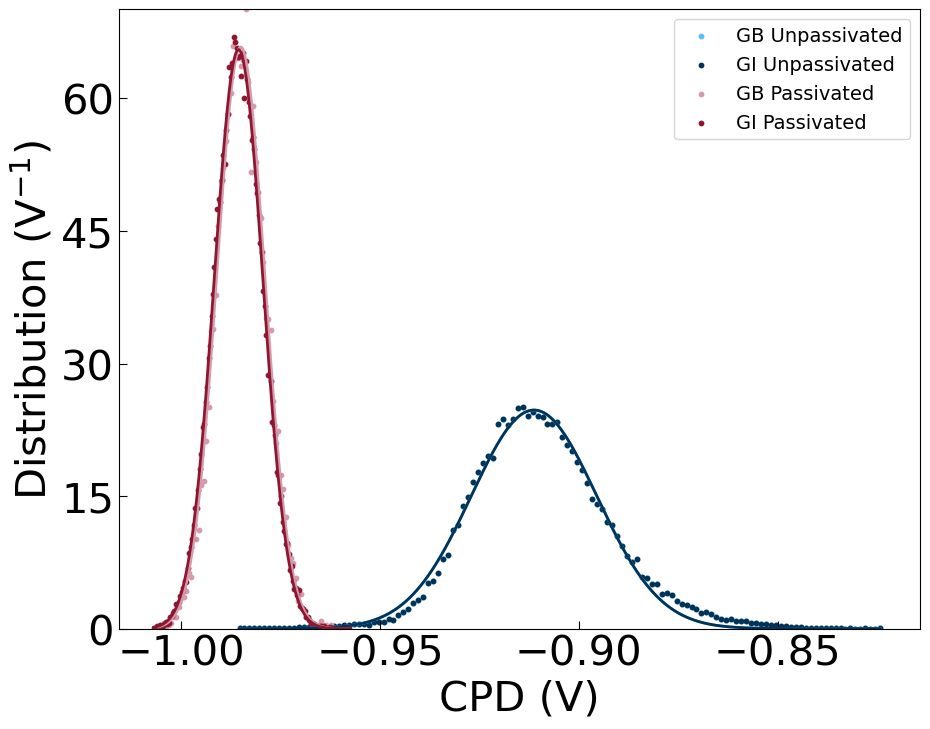

In [41]:
if processing_type == 'Y':
    grain_shapes()
elif processing_type == 'N':
    grain_boundaries()
else:
    print ("No processing type selected or error in code")